# Kalp Hastalıkları Tahmini - Heart Disease Prediction

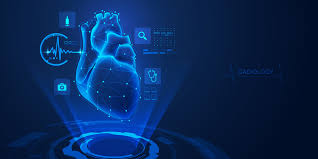


Bu projede, bireylerin demografik ve klinik özellikleri kullanılarak kalp hastalığı varlığının tahmin edilmesi amaçlanmıştır. Yaş, cinsiyet, kan basıncı, kolesterol seviyesi, maksimum kalp atış hızı ve egzersizle ilişkili semptomlar gibi değişkenler kullanılarak çeşitli makine öğrenmesi algoritmaları karşılaştırılmış ve en uygun model belirlenmeye çalışılmıştır.

## Sütun Açıklamaları

**Age** → Hastanın yaşıdır.

**Sex** → Hastanın cinsiyetini belirtir (1 = erkek, 0 = kadın).

**Chest pain type** → Hastanın yaşadığı göğüs ağrısı türünü gösterir.

**BP** → Hastanın dinlenme halindeki kan basıncıdır (mmHg).

**Cholesterol** → Kandaki toplam kolesterol seviyesidir.

**FBS over 120** → Açlık kan şekerinin 120 mg/dl’den yüksek olup olmadığını gösterir (1 = evet, 0 = hayır).

**EKG results** → Dinlenme halindeki elektrokardiyografi (EKG) sonuçlarını belirtir.

**Max HR** → Egzersiz sırasında ulaşılan maksimum kalp atış hızıdır.

**Exercise angina** → Egzersiz sırasında göğüs ağrısı oluşup oluşmadığını gösterir (1 = var, 0 = yok).

**ST depression** → Egzersiz sonrası ST segmentindeki depresyon miktarını gösterir.

**Slope of ST** → ST segmentinin eğimini belirtir.

**Number of vessels fluro** → Floroskopi ile görüntülenen ana damar sayısını gösterir.

**Thallium** → Talyum stres testinin sonucunu belirtir.

**Heart Disease** → Hastada kalp hastalığı olup olmadığını gösteren hedef değişkendir (Presence / Absence).

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/kalphastalktahmini/Heart_Disease_Prediction.csv
/kaggle/input/heart-foto/heart.jpg


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/kalphastalktahmini/Heart_Disease_Prediction.csv
/kaggle/input/heart-foto/heart.jpg


### Veri seti kaynağı

https://www.kaggle.com/datasets/neurocipher/heartdisease/data

In [3]:
# Temel veri işleme
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarıları kapatma
import warnings
warnings.filterwarnings("ignore")

# Veri bölme
from sklearn.model_selection import train_test_split

# Ölçekleme
from sklearn.preprocessing import StandardScaler

# Modeller
from sklearn.linear_model import LogisticRegression  # Baseline model; küçük veri setlerinde stabil çalışır ve lineer karar sınırı oluşturur.
from sklearn.ensemble import RandomForestClassifier  # Non-linear ilişkileri yakalayabilir; küçük veri setlerinde genelde güçlü performans verir.
from sklearn.ensemble import GradientBoostingClassifier # Hataları iteratif olarak düzeltir; kompleks veri yapılarında yüksek doğruluk sağlar.
from sklearn.neighbors import KNeighborsClassifier  # Benzer örnek mantığı ile çalışır; küçük veri setlerinde etkili olabilir.
from sklearn.svm import SVC # Margin maksimize eder; yüksek boyutlu veri ve küçük veri setlerinde güçlüdür.

# Performans Metrikleri
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/kalphastalktahmini/Heart_Disease_Prediction.csv")

df.head()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [5]:
df.shape


(270, 14)

In [6]:
df.columns


Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [8]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [9]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [10]:
df.corr(numeric_only=True)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Age,1.000000,-0.094401,0.096920,0.273053,0.220056,0.123458,0.128171,-0.402215,0.098297,0.194234,0.159774,0.356081,0.106100
Sex,-0.094401,1.000000,0.034636,-0.062693,-0.201647,0.042140,0.039253,-0.076101,0.180022,0.097412,0.050545,0.086830,0.391046
Chest pain type,0.096920,0.034636,1.000000,-0.043196,0.090465,-0.098537,0.074325,-0.317682,0.353160,0.167244,0.136900,0.225890,0.262659
BP,0.273053,-0.062693,-0.043196,1.000000,0.173019,0.155681,0.116157,-0.039136,0.082793,0.222800,0.142472,0.085697,0.132045
Cholesterol,0.220056,-0.201647,0.090465,0.173019,1.000000,0.025186,0.167652,-0.018739,0.078243,0.027709,-0.005755,0.126541,0.028836
FBS over 120,0.123458,0.042140,-0.098537,0.155681,0.025186,1.000000,0.053499,0.022494,-0.004107,-0.025538,0.044076,0.123774,0.049237
EKG results,0.128171,0.039253,0.074325,0.116157,0.167652,0.053499,1.000000,-0.074628,0.095098,0.120034,0.160614,0.114368,0.007337
Max HR,-0.402215,-0.076101,-0.317682,-0.039136,-0.018739,0.022494,-0.074628,1.000000,-0.380719,-0.349045,-0.386847,-0.265333,-0.253397
Exercise angina,0.098297,0.180022,0.353160,0.082793,0.078243,-0.004107,0.095098,-0.380719,1.000000,0.274672,0.255908,0.153347,0.321449
ST depression,0.194234,0.097412,0.167244,0.222800,0.027709,-0.025538,0.120034,-0.349045,0.274672,1.000000,0.609712,0.255005,0.324333


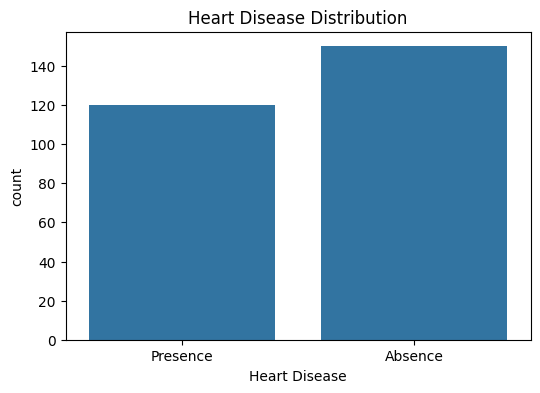

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Heart Disease", data=df)
plt.title("Heart Disease Distribution")
plt.show()


Veri setinde kalp hastalığı olmayan bireyler (Absence) hastalığı olanlardan (Presence) biraz daha fazladır ancak sınıflar genel olarak dengelidir.

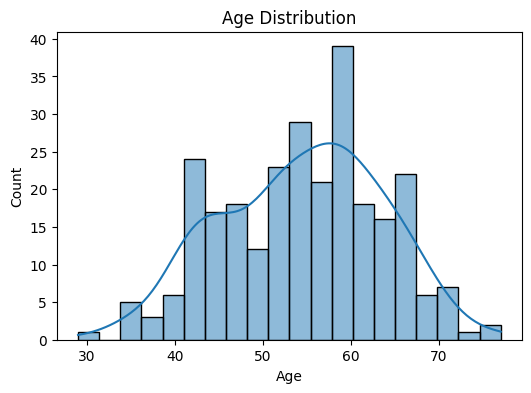

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


Yaş dağılımı çoğunlukla 45–65 aralığında yoğunlaşmakta ve yaklaşık normal dağılıma benzemektedir.

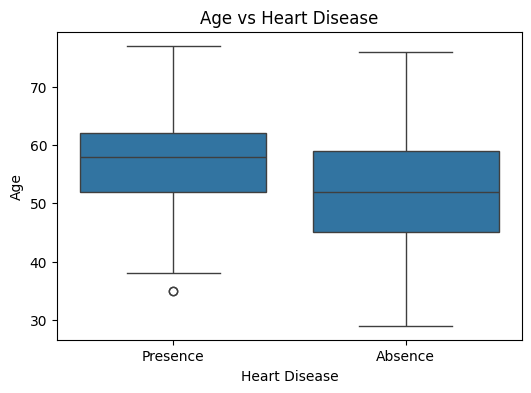

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Heart Disease", y="Age", data=df)
plt.title("Age vs Heart Disease")
plt.show()


Kalp hastalığı olan bireylerin medyan yaşı, hastalığı olmayanlara göre biraz daha yüksektir.

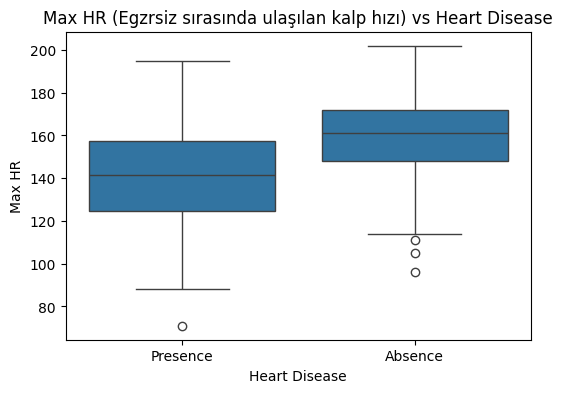

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Heart Disease", y="Max HR", data=df)
plt.title("Max HR (Egzrsiz sırasında ulaşılan kalp hızı) vs Heart Disease")
plt.show()


Kalp hastalığı olan bireylerde maksimum kalp atış hızı genellikle daha düşüktür.

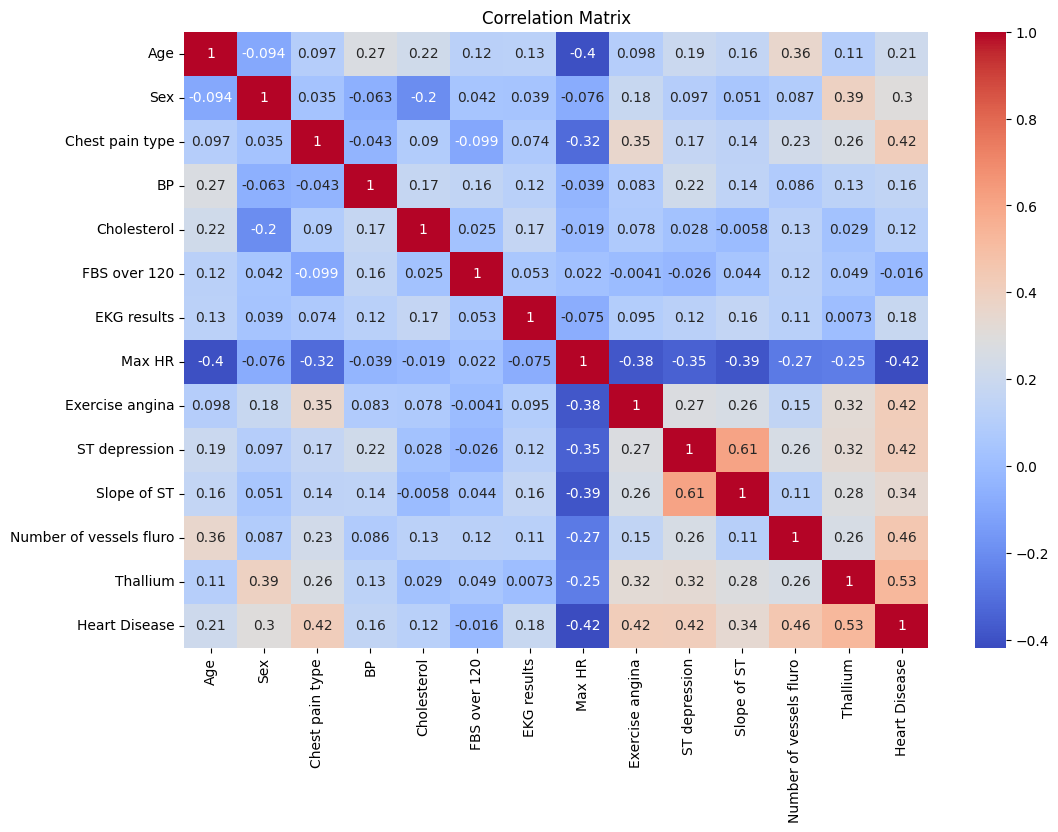

In [15]:
df_temp = df.copy()
df_temp["Heart Disease"] = df_temp["Heart Disease"].map({"Absence":0, "Presence":1})

plt.figure(figsize=(12,8))
sns.heatmap(df_temp.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Kalp hastalığı ile en güçlü pozitif ilişki Thallium, Number of vessels fluro, ST depression ve Chest pain type değişkenlerinde; en güçlü negatif ilişki ise Max HR değişkenindedir.

In [16]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})


In [17]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [18]:
x = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]


In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)


In [20]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier()
model1.fit(x_train, y_train)   # Tree modeller scale gerektirmez
tahmin1 = model1.predict(x_test)
print("Accuracy:",accuracy_score(y_test, tahmin1))


Accuracy: 0.9074074074074074


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [22]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()

model2.fit(x_train_scaled, y_train)   # Scale gerekli
tahmin2 = model2.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, tahmin2))


Accuracy: 0.9074074074074074


In [23]:
from sklearn.ensemble import GradientBoostingClassifier

model3 = GradientBoostingClassifier()

model3.fit(x_train, y_train)   # Tree modeller scale gerektirmez
tahmin3 = model3.predict(x_test)

print("Accuracy:", accuracy_score(y_test, tahmin3))


Accuracy: 0.7407407407407407


In [24]:
from sklearn.neighbors import KNeighborsClassifier

model4 = KNeighborsClassifier()

model4.fit(x_train_scaled, y_train)   # Distance bazlı olduğu için scale gerekli
tahmin4 = model4.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, tahmin4))


Accuracy: 0.8148148148148148


In [25]:
from sklearn.svm import SVC

model5 = SVC()

model5.fit(x_train_scaled, y_train)   # Scale gerekli
tahmin5 = model5.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, tahmin5))


Accuracy: 0.8888888888888888


In [26]:
print("Random Forest Accuracy       :", accuracy_score(y_test, tahmin1))
print("Logistic Regression Accuracy :", accuracy_score(y_test, tahmin2))
print("Gradient Boosting Accuracy   :", accuracy_score(y_test, tahmin3))
print("KNN Accuracy                 :", accuracy_score(y_test, tahmin4))
print("SVM Accuracy                 :", accuracy_score(y_test, tahmin5))


Random Forest Accuracy       : 0.9074074074074074
Logistic Regression Accuracy : 0.9074074074074074
Gradient Boosting Accuracy   : 0.7407407407407407
KNN Accuracy                 : 0.8148148148148148
SVM Accuracy                 : 0.8888888888888888


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def algo_test(x, y):

    # ==============================
    # Modeller
    # ==============================
    LR  = LogisticRegression()
    RF  = RandomForestClassifier(random_state=42)
    GBR = GradientBoostingClassifier(random_state=42)
    ETR = ExtraTreesClassifier(random_state=42)
    KNN = KNeighborsClassifier()
    DT  = DecisionTreeClassifier(random_state=42)
    SVM = SVC()

    algos = [LR, RF, GBR, ETR, KNN, DT, SVM]
    algo_names = [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees",
        "KNN",
        "Decision Tree",
        "SVM"
    ]

    # ==============================
    # Train-Test Split
    # ==============================
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    accuracy = []
    precision = []
    recall = []
    f1 = []

    # ==============================
    # Model eğitimi ve değerlendirme
    # ==============================
    for algo in algos:
        y_pred = algo.fit(x_train, y_train).predict(x_test)

        accuracy.append(accuracy_score(y_test, y_pred))
        precision.append(precision_score(y_test, y_pred))
        recall.append(recall_score(y_test, y_pred))
        f1.append(f1_score(y_test, y_pred))

    result = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }, index=algo_names)

    return result.sort_values("Accuracy", ascending=False)


In [28]:
algo_test(x, y)

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.907407,0.944444,0.809524,0.871795
Extra Trees,0.833333,0.833333,0.714286,0.769231
Random Forest,0.796296,0.777778,0.666667,0.717949
Gradient Boosting,0.777778,0.764706,0.619048,0.684211
Decision Tree,0.685185,0.576923,0.714286,0.638298
KNN,0.648148,0.541667,0.619048,0.577778
SVM,0.629630,0.533333,0.380952,0.444444


Logistic Regression, %90 doğruluk → Çok iyi

Precision yüksek → Hasta dediği kişilerin çoğu gerçekten hasta

Recall %80 → Hastaların %80’ini yakalıyor

F1 dengeli → Model stabil

Bu veri seti lineer ayrılabilir yapıya sahip görünüyor.
Bu yüzden Logistic Regression en iyi sonucu verdi.

Not: scale yapılmazsa SVM ve KNN genelde kötü performans verir.

## Şimdi veri setinden rastgele bir kişinin kalp hastası olma olasılığına bakalım.

In [29]:
import numpy as np

# Test setinden rastgele bir kişi seçelim
i = np.random.randint(0, len(x_test_scaled))

tek_ornek = x_test_scaled[i].reshape(1, -1)

# Olasılık, tahmin ve gerçek değer
olasilik = model2.predict_proba(tek_ornek)[0,1]
tahmin = model2.predict(tek_ornek)[0]
gercek = y_test.iloc[i]

# Sonucu tablo halinde gösterelim
pd.DataFrame({
    "Gerçek Değer": [gercek],
    "Model Tahmini": [tahmin],
    "Hastalık Olasılığı (%)": [round(olasilik*100,2)]
})


,Gerçek Değer,Model Tahmini,Hastalık Olasılığı (%)
0,0,0,9.98


Bu şu demek:

Gerçek kişi hasta değil (0)

Model de hasta değil dedi

Ama model bu kişide %35 risk görüyor

Yani model şunu söylüyor:

"Bu kişi düşük riskli değil ama eşik değerin (%50) altında olduğu için sağlıklı sınıfına koyuyorum."

## Sonuç

Yapılan model karşılaştırmaları sonucunda Logistic Regression modeli %90 doğruluk oranı ile en yüksek performansı göstermiştir. Elde edilen sonuçlar, veri setinin lineer ayrılabilir özellikler taşıdığını ve uygun bir model seçimiyle kalp hastalığı tahmininde yüksek başarı elde edilebileceğini göstermektedir. Bu çalışma, makine öğrenmesinin tıbbi karar destek sistemlerinde etkili bir araç olarak kullanılabileceğini ortaya koymaktadır.